<a href="https://colab.research.google.com/github/vijayakanth/Transfer-Learning/blob/main/pre_trained_ml_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================
# SECTION 0: DEPENDENCIES + GLOBAL SETUP
# ================================================

import os, sys, glob, random, importlib.util, subprocess
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization,
    Conv2D, DepthwiseConv2D, Activation, Reshape, Add, LayerNormalization,
    MultiHeadAttention, Lambda
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ====== REPRODUCIBILITY ======
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================
# ENVIRONMENT DETECTION
# ================================================
IS_KAGGLE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '') != ''
IS_COLAB  = 'google.colab' in sys.modules and not IS_KAGGLE
IS_LOCAL  = not IS_KAGGLE and not IS_COLAB

print(f"Environment : {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")
print(f"TF Version  : {tf.__version__}")
print(f"GPU         : {[g.name for g in tf.config.list_physical_devices('GPU')] or 'None'}")

# ================================================
# GOOGLE DRIVE MOUNT (Colab only)
# ================================================
if IS_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
        print("✅ Google Drive mounted.")
    else:
        print("✅ Google Drive already mounted.")

# ================================================
# PATHS
# ================================================
if IS_KAGGLE:
    DATA_DIR = "/kaggle/input/datasets/vijayakanthan/sl-tealeafdisease/SriLankan_TeaLeaf_5968"
    SAVE_DIR = "/kaggle/working/outputs"

elif IS_COLAB:
    DATA_DIR = "/content/drive/MyDrive/ColabNotebooks/data/SriLankan_TeaLeaf_5968"
    SAVE_DIR = "/content/drive/MyDrive/ColabNotebooks/outputs"

else:  # Local
    DATA_DIR = "/Volumes/Education/Dataset/SriLankan_TeaLeaf_5968"
    SAVE_DIR  = "./outputs"

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"DATA_DIR : {DATA_DIR}")
print(f"SAVE_DIR : {SAVE_DIR}")

# ================================================
# SANITY CHECK — verify class folders exist
# ================================================
if os.path.exists(DATA_DIR):
    classes = sorted([d for d in os.listdir(DATA_DIR)
                      if os.path.isdir(os.path.join(DATA_DIR, d))])
    print(f"✅ Found {len(classes)} classes: {classes}")
else:
    raise FileNotFoundError(f"❌ DATA_DIR does not exist: {DATA_DIR}")

# ================================================
# GPU MEMORY GROWTH (prevents OOM on Kaggle/Colab)
# ================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth enabled for {len(gpus)} GPU(s).")
    except RuntimeError as e:
        print(f"⚠️ Memory growth setting failed: {e}")

# ================================================
# GLOBAL HYPERPARAMETERS
# ================================================
NUM_CLASSES  = 6
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS_P1    = 20      # Phase 1: frozen base (MobileNetV2)
EPOCHS_P2    = 50      # Phase 2: full fine-tune (MobileNetV2)
EPOCHS_VIT   = 50      # MobileViT: single phase (from scratch)
LR_P1        = 3e-4
LR_P2        = 1e-5
LR_VIT       = 3e-4
LABEL_SMOOTH = 0.02
DROPOUT      = 0.3

print("\n====== Hyperparameters ======")
print(f"  Image Size   : {IMG_SIZE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Num Classes  : {NUM_CLASSES}")
print(f"  Epochs P1/P2 : {EPOCHS_P1} / {EPOCHS_P2}")
print(f"  Epochs ViT   : {EPOCHS_VIT}")
print(f"  LR P1/P2/ViT : {LR_P1} / {LR_P2} / {LR_VIT}")
print("="*30)

2026-05-13 13:44:27.477726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778679867.983224      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778679868.126387      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778679869.145885      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778679869.145923      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778679869.145927      23 computation_placer.cc:177] computation placer alr

Environment : Kaggle
TF Version  : 2.19.0
GPU         : ['/physical_device:GPU:0', '/physical_device:GPU:1']
DATA_DIR : /kaggle/input/datasets/vijayakanthan/sl-tealeafdisease/SriLankan_TeaLeaf_5968
SAVE_DIR : /kaggle/working/outputs
✅ Found 6 classes: ['Algal_leaf_spot', 'Black_blight', 'Blister_blight', 'Gray_blight', 'Healthy', 'Spider_mites']
✅ Memory growth enabled for 2 GPU(s).

====== Hyperparameters ======
  Image Size   : (224, 224)
  Batch Size   : 32
  Num Classes  : 6
  Epochs P1/P2 : 20 / 50
  Epochs ViT   : 50
  LR P1/P2/ViT : 0.0003 / 1e-05 / 0.0003


Total Dataset: 5968 images across 6 classes.
Train : 4177 (70.0%)
Val   : 596   (10.0%)
Test  : 1195  (20.0%)

  MODEL 1: MobileNetV2 (Pretrained ImageNet)


I0000 00:00:1778679978.763475      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778679978.769452      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 28/131 ━━━━━━━━━━━━━━━━━━━━ 29s 285ms/step - accuracy: 0.3712 - loss: 1.5990

2026-05-13 14:03:48.141304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 14:03:48.274343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 14:03:50.021304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 14:03:50.225564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 14:03:51.393241: E external/local_xla/xla/stream_

131/131 ━━━━━━━━━━━━━━━━━━━━ 179s 783ms/step - accuracy: 0.4874 - loss: 1.3282 - val_accuracy: 0.2081 - val_loss: 1.9048 - learning_rate: 3.0000e-04
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 297ms/step - accuracy: 0.6946 - loss: 0.8360 - val_accuracy: 0.2081 - val_loss: 2.0305 - learning_rate: 3.0000e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 293ms/step - accuracy: 0.7941 - loss: 0.6276 - val_accuracy: 0.1628 - val_loss: 2.1927 - learning_rate: 3.0000e-04
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 293ms/step - accuracy: 0.8434 - loss: 0.5150 - val_accuracy: 0.1628 - val_loss: 3.7702 - learning_rate: 3.0000e-04
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 299ms/step - accuracy: 0.8978 - loss: 0.3902 - val_accuracy: 0.3557 - val_loss: 2.2797 - learning_rate: 3.0000e-04
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 300ms/step - accuracy: 0.9322 - loss: 0.3031 - val_accuracy: 0.7886 - val_loss: 0.7306 - learning_rate: 1.5000e-04
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 300ms/step -

2026-05-13 14:20:55.544368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 14:20:55.680098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 338ms/step
Test Loss: 0.2340 | Test Accuracy: 97.24%

Classification Report:
                 precision    recall  f1-score   support

Algal_leaf_spot       0.96      0.96      0.96       248
   Black_blight       0.98      0.93      0.95       194
 Blister_blight       0.98      1.00      0.99       151
    Gray_blight       0.95      0.96      0.96       250
        Healthy       0.99      0.99      0.99       195
   Spider_mites       0.99      1.00      0.99       157

       accuracy                           0.97      1195
      macro avg       0.97      0.98      0.97      1195
   weighted avg       0.97      0.97      0.97      1195



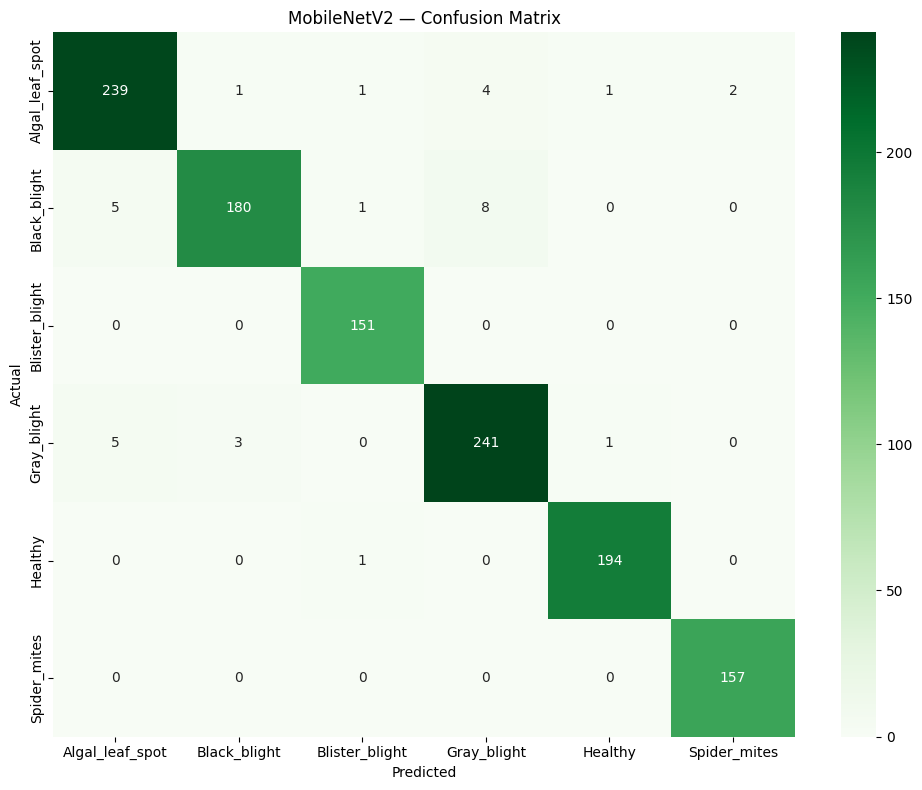


  Evaluating: MobileViT
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 396ms/step
Test Loss: 0.2974 | Test Accuracy: 93.81%

Classification Report:
                 precision    recall  f1-score   support

Algal_leaf_spot       0.92      0.93      0.92       248
   Black_blight       0.90      0.86      0.88       194
 Blister_blight       0.97      0.98      0.97       151
    Gray_blight       0.94      0.95      0.94       250
        Healthy       0.96      0.95      0.95       195
   Spider_mites       0.97      0.98      0.97       157

       accuracy                           0.94      1195
      macro avg       0.94      0.94      0.94      1195
   weighted avg       0.94      0.94      0.94      1195



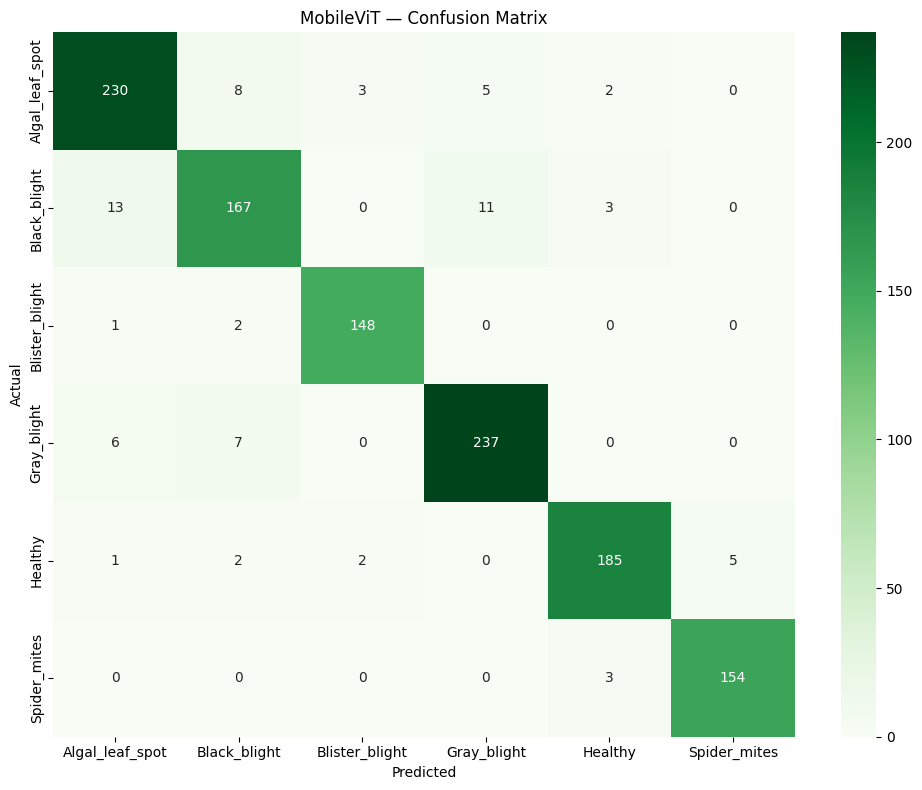

INFO:tensorflow:Assets written to: /tmp/tmptycvvz1w/assets


INFO:tensorflow:Assets written to: /tmp/tmptycvvz1w/assets


Saved artifact at '/tmp/tmptycvvz1w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135317540517840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317537719120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317537718352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317540518032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317540518800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317540518608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317537719888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317537720848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317537720464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317537720080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1353175377

W0000 00:00:1778682115.678508      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778682115.678542      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778682115.826814      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite saved: /kaggle/working/outputs/mobilenetv2.tflite
INFO:tensorflow:Assets written to: /tmp/tmpg_ebhooo/assets


INFO:tensorflow:Assets written to: /tmp/tmpg_ebhooo/assets


Saved artifact at '/tmp/tmpg_ebhooo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135317392223184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317392227600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317392220880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317392228176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317392220304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317392220496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308814990416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308814991184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135317392225296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135308814989840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1353088149

W0000 00:00:1778682126.716825      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778682126.716866      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TFLite saved: /kaggle/working/outputs/mobilevit.tflite


In [ ]:

# ====== DATA LOADER ======
def getImages(data_dir=DATA_DIR, no_of_classes=6, target_size=(224, 224)):
    images, labels = [], []
    class_dirs = sorted([d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)])
    class_dirs = class_dirs[:no_of_classes]

    for cls_path in class_dirs:
        label = os.path.basename(cls_path)
        for img_path in glob.glob(os.path.join(cls_path, "*.jpg")):
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)

    images = np.array(images, dtype=np.uint8)
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    label_to_id  = {lab: i for i, lab in enumerate(unique_labels)}
    id_to_label  = {i: lab for lab, i in label_to_id.items()}
    label_ids    = np.array([label_to_id[x] for x in labels], dtype=np.int64)

    print(f"Total Dataset: {images.shape[0]} images across {len(unique_labels)} classes.")
    return images, label_ids, id_to_label

# Load Data
disease_imgs, disease_labels, id_to_label = getImages()
numClasses   = len(id_to_label)
target_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

# ====== SPLIT DATA (Train 70%, Val 10%, Test 20%) ======
X_train, X_temp, y_train_idx, y_temp_idx = train_test_split(
    disease_imgs, disease_labels, test_size=0.3, random_state=SEED, stratify=disease_labels
)
X_val, X_test, y_val_idx, y_test_idx = train_test_split(
    X_temp, y_temp_idx, test_size=0.667, random_state=SEED, stratify=y_temp_idx
)

# Sanity check
total = len(disease_imgs)
print(f"Train : {len(X_train)} ({len(X_train)/total*100:.1f}%)")
print(f"Val   : {len(X_val)}   ({len(X_val)/total*100:.1f}%)")
print(f"Test  : {len(X_test)}  ({len(X_test)/total*100:.1f}%)")

# Convert to Categorical
Y_train = to_categorical(y_train_idx, numClasses)
Y_val   = to_categorical(y_val_idx,   numClasses)
Y_test  = to_categorical(y_test_idx,  numClasses)

# Class Weights
weights           = compute_class_weight('balanced', classes=np.unique(y_train_idx), y=y_train_idx)
class_weight_dict = dict(enumerate(weights))

# ====== AUGMENTATION ======
train_datagen = ImageDataGenerator(
    rescale=1./255,

)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow(X_train, Y_train, batch_size=32, shuffle=True)
val_gen   = val_test_datagen.flow(X_val, Y_val,   batch_size=32, shuffle=False)

# Normalized test array
X_test_norm = X_test.astype(np.float32) / 255.0


# ======================================================
# MODEL 1: MobileNetV2 (Pretrained ImageNet)
# ======================================================
def build_mobilenetv2(input_shape=(224, 224, 3), num_classes=6):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze for Phase 1

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=AdamW(3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
        metrics=['accuracy']
    )
    return model, base_model


# ======================================================
# MODEL 2: MobileViT-v1 (Built from scratch in Keras)
# Follows the official Apple MobileViT-Small architecture
# ======================================================
def mv2_block(x, filters, strides=1):
    """Inverted residual block used inside MobileViT."""
    in_channels = x.shape[-1]
    use_residual = (strides == 1 and in_channels == filters)

    # Expand
    expanded = filters * 4
    out = Conv2D(expanded, 1, padding='same', use_bias=False)(x)
    out = BatchNormalization()(out)
    out = Activation('swish')(out)

    # Depthwise
    out = DepthwiseConv2D(3, strides=strides, padding='same', use_bias=False)(out)
    out = BatchNormalization()(out)
    out = Activation('swish')(out)

    # Project
    out = Conv2D(filters, 1, padding='same', use_bias=False)(out)
    out = BatchNormalization()(out)

    if use_residual:
        out = Add()([x, out])
    return out


def mobilevit_block(x, filters, patch_size=2, num_heads=1, mlp_dim=128):
    """
    MobileViT block:
    Local representation → Unfold patches → Transformer → Fold → Fusion
    """
    _, H, W, C = x.shape
    # Local representation
    local = Conv2D(filters, 3, padding='same', use_bias=False)(x)
    local = BatchNormalization()(local)
    local = Activation('swish')(local)
    local = Conv2D(filters, 1, padding='same', use_bias=False)(local)

    # Unfold: (B, H, W, C) → (B, N_patches, patch_area, C)
    # patch_size x patch_size spatial patch
    ph = pw = patch_size
    nph = H // ph   # number of patches along height
    npw = W // pw   # number of patches along width
    N   = nph * npw  # total patches
    L   = ph * pw    # tokens per patch

    # Reshape to patches
    patches = Reshape((nph, ph, npw, pw, filters))(local)
    # (B, nph, ph, npw, pw, C) → (B, nph, npw, ph, pw, C)
    patches = Lambda(lambda t: tf.transpose(t, [0, 1, 3, 2, 4, 5]))(patches)
    # (B, N, L, C)
    patches = Reshape((N, L, filters))(patches)

    # Transformer (global self-attention across patches)
    attn = LayerNormalization()(patches)
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=filters // num_heads)(attn, attn)
    attn = Add()([patches, attn])

    ffn = LayerNormalization()(attn)
    ffn = Dense(mlp_dim, activation='swish')(ffn)
    ffn = Dense(filters)(ffn)
    attn = Add()([attn, ffn])

    # Fold back: (B, N, L, C) → (B, H, W, C)
    out = Reshape((nph, npw, ph, pw, filters))(attn)
    out = Lambda(lambda t: tf.transpose(t, [0, 1, 3, 2, 4, 5]))(out)
    out = Reshape((H, W, filters))(out)

    # Fusion
    out = Conv2D(filters, 1, padding='same', use_bias=False)(out)
    out = BatchNormalization()(out)
    out = Activation('swish')(out)
    # Concat with original input and project
    out = tf.keras.layers.Concatenate()([x, out])
    out = Conv2D(filters, 1, padding='same', use_bias=False)(out)
    out = BatchNormalization()(out)
    out = Activation('swish')(out)
    return out


def build_mobilevit_small(input_shape=(224, 224, 3), num_classes=6):
    """
    MobileViT-Small:
    Stem → MV2 blocks → MobileViT blocks → GAP → Classifier
    Channel config follows the official paper (Table 1).
    """
    inputs = Input(shape=input_shape)

    # Stem
    x = Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)  # 112x112
    x = BatchNormalization()(x)
    x = Activation('swish')(x)

    # MV2 blocks — Stage 1
    x = mv2_block(x, 32, strides=1)                                        # 112x112

    # MV2 blocks — Stage 2
    x = mv2_block(x, 64, strides=2)                                        # 56x56
    x = mv2_block(x, 64, strides=1)
    x = mv2_block(x, 64, strides=1)

    # MV2 blocks — Stage 3
    x = mv2_block(x, 96, strides=2)                                        # 28x28
    x = mv2_block(x, 96, strides=1)
    x = mv2_block(x, 96, strides=1)

    # MobileViT block — Stage 3 (28x28)
    x = mobilevit_block(x, filters=96, patch_size=2, num_heads=1, mlp_dim=192)

    # MV2 blocks — Stage 4
    x = mv2_block(x, 128, strides=2)                                       # 14x14
    # MobileViT block — Stage 4 (14x14)
    x = mobilevit_block(x, filters=128, patch_size=2, num_heads=2, mlp_dim=256)

    # MV2 blocks — Stage 5
    x = mv2_block(x, 160, strides=2)                                       # 7x7
    # MobileViT block — Stage 5 (7x7) — patch_size=1 for 7x7 feature map
    x = mobilevit_block(x, filters=160, patch_size=1, num_heads=3, mlp_dim=320)

    # Final projection
    x = Conv2D(320, 1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)

    # Classifier Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=AdamW(3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
        metrics=['accuracy']
    )
    return model


# ======================================================
# BUILD & TRAIN — MobileNetV2
# ======================================================
print("\n" + "="*55)
print("  MODEL 1: MobileNetV2 (Pretrained ImageNet)")
print("="*55)
mobilenetv2_model, mobilenetv2_base = build_mobilenetv2(num_classes=numClasses)
mobilenetv2_model.summary()

callbacks_v2 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0),
    ModelCheckpoint(os.path.join(SAVE_DIR, "best_mobilenetv2.keras"),
                    monitor='val_accuracy', save_best_only=True)
]

print("\n[MobileNetV2] Phase 1: Training head only (frozen base)...")
history_v2_p1 = mobilenetv2_model.fit(
    train_gen, validation_data=val_gen,
    epochs=20, class_weight=class_weight_dict,
    callbacks=callbacks_v2, verbose=1
)

print("\n[MobileNetV2] Phase 2: Fine-tuning full model...")
mobilenetv2_base.trainable = True
mobilenetv2_model.compile(
    optimizer=AdamW(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)
history_v2_p2 = mobilenetv2_model.fit(
    train_gen, validation_data=val_gen,
    epochs=50, class_weight=class_weight_dict,
    callbacks=callbacks_v2, verbose=1
)


# ======================================================
# BUILD & TRAIN — MobileViT-Small
# ======================================================
print("\n" + "="*55)
print("  MODEL 2: MobileViT-Small (Keras, trained from scratch)")
print("="*55)
mobilevit_model = build_mobilevit_small(num_classes=numClasses)
mobilevit_model.summary()

callbacks_vit = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0),
    ModelCheckpoint(os.path.join(SAVE_DIR, "best_mobilevit.keras"),
                    monitor='val_accuracy', save_best_only=True)
]

print("\n[MobileViT] Training...")
history_vit = mobilevit_model.fit(
    train_gen, validation_data=val_gen,
    epochs=50, class_weight=class_weight_dict,
    callbacks=callbacks_vit, verbose=1
)


# ======================================================
# EVALUATION
# ======================================================
def evaluate_model(model, model_name, X_test_norm, Y_test,
                   y_test_idx, target_names, SAVE_DIR):
    print(f"\n{'='*55}")
    print(f"  Evaluating: {model_name}")
    print(f"{'='*55}")

    y_pred_probs = model.predict(X_test_norm, batch_size=32)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    test_loss, test_acc = model.evaluate(X_test_norm, Y_test, batch_size=32, verbose=0)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test_idx, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test_idx, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{model_name}_cm.png"))
    plt.show()

evaluate_model(mobilenetv2_model, "MobileNetV2", X_test_norm, Y_test,
               y_test_idx, target_names, SAVE_DIR)
evaluate_model(mobilevit_model,   "MobileViT",   X_test_norm, Y_test,
               y_test_idx, target_names, SAVE_DIR)


# ======================================================
# SAVE AS TFLITE
# ======================================================
def save_tflite(model, filename, SAVE_DIR):
    converter    = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    path         = os.path.join(SAVE_DIR, filename)
    with open(path, "wb") as f:
        f.write(tflite_model)
    print(f"TFLite saved: {path}")

save_tflite(mobilenetv2_model, "mobilenetv2.tflite", SAVE_DIR)
save_tflite(mobilevit_model,   "mobilevit.tflite",   SAVE_DIR)